In [1]:
# ==============================================================
# Brain Tumor Classification - Library Imports and Setup
# ==============================================================

# ------------------------------
# Standard Libraries
# ------------------------------
import os                      # For handling file paths and directories
import sys                     # System-specific parameters and functions
from collections import Counter  # For counting occurrences in lists

# ------------------------------
# Data Science Libraries
# ------------------------------
import numpy as np             # For numerical operations
import pandas as pd            # For data manipulation
import matplotlib              # Core matplotlib library
import matplotlib.pyplot as plt  # For plotting graphs
import PIL                     # Python Imaging Library
from PIL import Image          # For image loading and processing

# ------------------------------
# PyTorch Libraries
# ------------------------------
import torch                    # Core PyTorch library
import torch.nn as nn           # For building neural networks
import torch.optim as optim     # For optimization algorithms
import torchvision              # For computer vision datasets and models
from torchvision import datasets, transforms, models  # Dataset handling and transformations and pretrained model importation
from torch.utils.data import DataLoader, random_split  # Loading and splitting datasets
from torchinfo import summary   # For model summary visualization

# ------------------------------
# Machine Learning Utilities
# ------------------------------
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix  # Model evaluation

# ------------------------------
# Progress Tracking
# ------------------------------
from tqdm.notebook import tqdm  # For progress bars in notebooks

# ------------------------------
# Reproducibility Settings
# ------------------------------
torch.backends.cudnn.deterministic = True  # Ensure deterministic results on CUDA


In [2]:
# ==============================================================
# Environment and Library Version Check
# ==============================================================

# ------------------------------
# System Information
# ------------------------------
print("Platform:", sys.platform)        # Prints the operating system/platform
print("Python version:", sys.version)   # Prints the Python version in use
print("---")                            # Separator for readability

# ------------------------------
# Library Versions
# ------------------------------
print("matplotlib version:", matplotlib.__version__)    # Prints matplotlib version
print("pandas version:", pd.__version__)                # Prints pandas version
print("PIL version:", PIL.__version__)                  # Prints PIL/Pillow version
print("torch version:", torch.__version__)              # Prints PyTorch version
print("torchvision version:", torchvision.__version__)  # Prints torchvision version
print("---")                                            # Separator for readability


Platform: linux
Python version: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
---
matplotlib version: 3.7.2
pandas version: 2.2.3
PIL version: 11.3.0
torch version: 2.6.0+cu124
torchvision version: 0.21.0+cu124
---


In [3]:
# ==============================================================
#  Device Configuration for PyTorch
# ==============================================================

# Check if CUDA (GPU) is available; otherwise, use CPU
if torch.cuda.is_available():
    device = "cuda"                                # Set device to GPU
    print(f"Using device: {device}")               # Confirm GPU usage
else:
    device = "cpu"                                 # Fallback to CPU
    print(f"Using device: {device}")               # Confirm CPU usage


Using device: cuda


In [4]:
# ==============================================================
# Image Transformations and Augmentation
# ==============================================================

# ------------------------------
# 1. Custom Transformation: Convert Images to RGB
# ------------------------------
class ConvertToRGB:
    """Ensure all images are in RGB mode."""
    def __call__(self, img):
        if img.mode != "RGB":        # Check if image is already RGB
            img = img.convert("RGB") # Convert to RGB if not
        return img

# ------------------------------
# 2. Training Image Transformations
# ------------------------------
# Apply data augmentation to improve model generalization
train_transforms = transforms.Compose([
    ConvertToRGB(),                       # Ensure RGB images
    transforms.Resize((256, 256)),        # Resize all images to 256x256
    transforms.RandomCrop((224, 224)),    # Randomly crop to 224x224
    transforms.RandomHorizontalFlip(p=0.5), # Random horizontal flip
    transforms.RandomRotation(degrees=15),  # Random rotation up to ±15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Adjust brightness & contrast
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)), # Apply Gaussian blur
    transforms.ToTensor(),                # Convert PIL image to PyTorch tensor
    transforms.Normalize(                 # Normalize using ImageNet stats
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------------------------
# 3. Validation / Test Transformations
# ------------------------------
# No augmentation for validation/test; only resizing and normalization
val_transforms = transforms.Compose([
    ConvertToRGB(),                        # Ensure RGB images
    transforms.Resize((224, 224)),         # Resize to 224x224
    transforms.ToTensor(),                 # Convert to tensor
    transforms.Normalize(                  # Normalize using ImageNet stats
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------------------------
# 4. Print Transform Pipelines
# ------------------------------
print("Training transforms:")
print(train_transforms)
print("\nValidation transforms:")
print(val_transforms)


Training transforms:
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation transforms:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [5]:
# ==============================================================
# 2. Load Dataset Paths
# ==============================================================

# ------------------------------
# Define directory paths for datasets
# ------------------------------

# Path to training dataset
train_dir = "/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"   # Replace with your train folder path

# Print train directory
print(' The Train Dairectory :', train_dir)

 The Train Dairectory : /kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT


In [6]:

# Load dataset without splitting
full_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)

# Define split sizes
train_size = int(0.8 * len(full_dataset))
valid_size = len(full_dataset) - train_size

# Split the dataset
train_datasets, validation_datasets = random_split(full_dataset, [train_size, valid_size])
classes = full_dataset.classes
print("Length of train_datasets :", len(train_datasets))
print("Length of validation_datasets :", len(validation_datasets))
print("Classes of dataset :", full_dataset.classes)


Length of train_datasets : 1262
Length of validation_datasets : 316
Classes of dataset : ['benign', 'malignant', 'normal']


In [7]:
# ------------------------------
# 4.1 Count number of images per class in training dataset
# ------------------------------
class_counts = Counter([label for _, label in train_datasets])  # Count labels in training set

# Print class distribution
for class_index, count in class_counts.items():
    class_name = classes[class_index]                        # Get class name
    print(f"Class '{class_name}' has {count} images.")           # Print count per class


Class 'benign' has 711 images.
Class 'malignant' has 338 images.
Class 'normal' has 213 images.


In [8]:
# ==============================================================
# 6. Create DataLoaders
# ==============================================================

# ------------------------------
# 6.1 Set batch size and random generator for reproducibility
# ------------------------------
batch_size = 32                  # Number of samples per batch
g = torch.Generator()            # Create a random generator
g.manual_seed(42)                # Set seed for reproducibility

# ------------------------------
# 6.2 Create DataLoaders for training, validation, and test sets
# ------------------------------
train_loader = DataLoader(
    train_datasets,              # Training dataset
    batch_size=batch_size,       # Batch size
    shuffle=True,                # Shuffle training data for better generalization
    generator=g                  # Use seeded generator for reproducibility
)

val_loader = DataLoader(
    validation_datasets,         # Validation dataset
    batch_size=batch_size,       # Batch size
    shuffle=False,               # Do not shuffle validation data
    generator=g
)

# ------------------------------
# 6.3 Print number of batches in each DataLoader
# ------------------------------
print(f"Train batches: {len(train_loader)}")   # Total number of training batches
print(f"Val batches: {len(val_loader)}")       # Total number of validation batches


# ------------------------------
# 6.4 Verify batch shape
# ------------------------------
single_batch = next(iter(train_loader))[0]     # Get first batch of images
print(f"Shape of one batch: {single_batch.shape}")  # Should be (batch_size, channels, height, width)

Train batches: 40
Val batches: 10
Shape of one batch: torch.Size([32, 3, 224, 224])


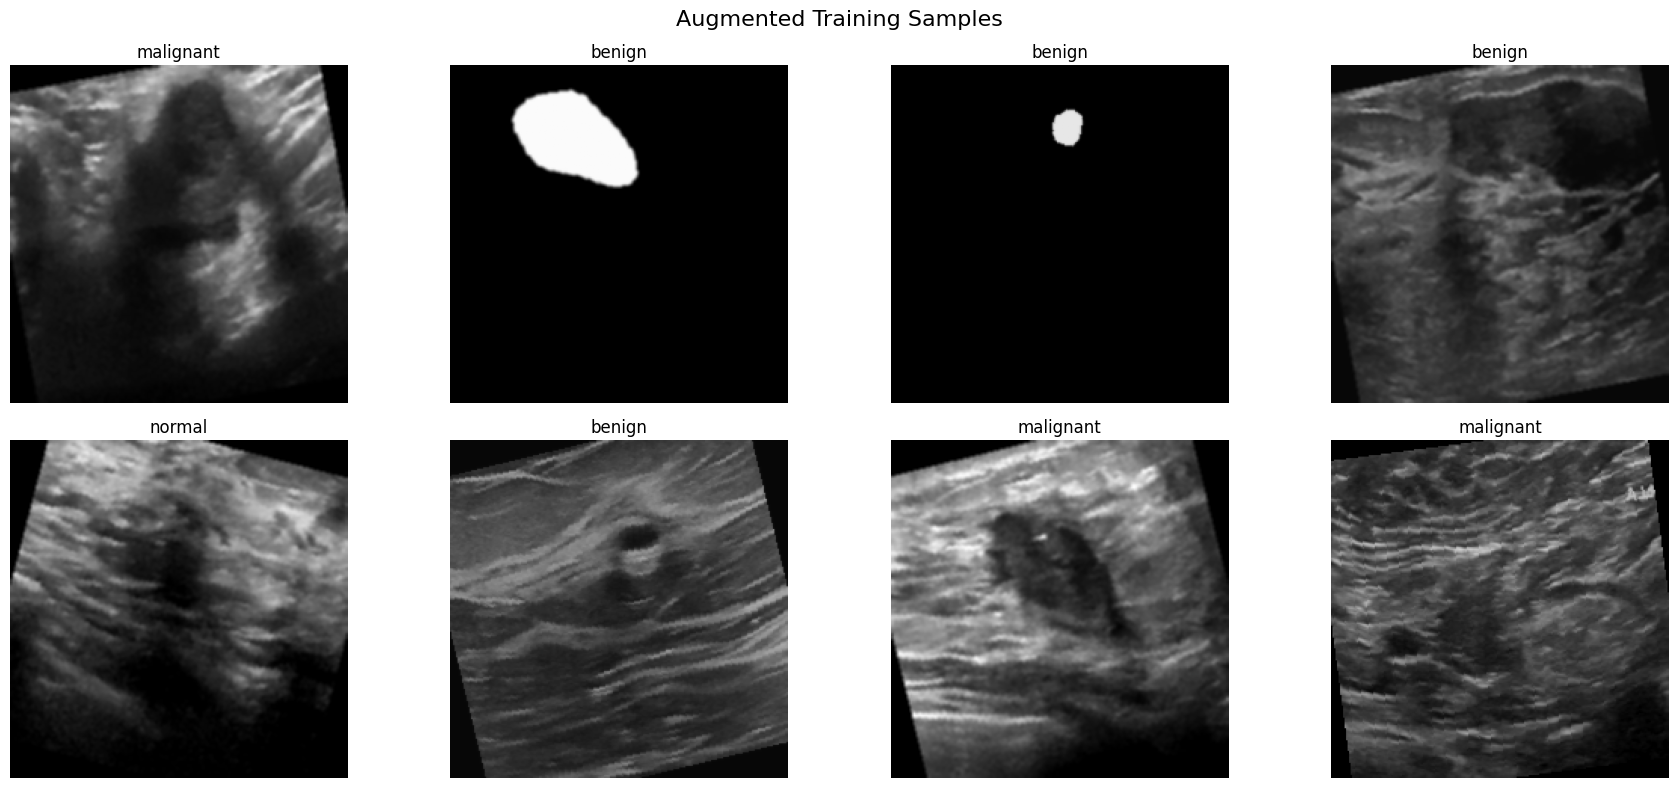

In [9]:
# ================================
# 4. VISUALIZE AUGMENTED SAMPLES
# ================================

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i in range(8):
    img = images[i].permute(1, 2, 0)  # C,H,W -> H,W,C
    # Denormalize for visualization
    img = img * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
    img = torch.clamp(img, 0, 1)
    
    ax = axes[i//4, i%4]
    ax.imshow(img)
    ax.set_title(f"{classes[labels[i]]}")
    ax.axis('off')

plt.suptitle("Augmented Training Samples", fontsize=16)
plt.tight_layout()
plt.show()


In [10]:
# ==============================================================
# 8. Compute Class Weights for Imbalanced Dataset
# ==============================================================

# ------------------------------
# 8.1 Import required library
# ------------------------------
from sklearn.utils.class_weight import compute_class_weight  # To calculate class weights
import numpy as np                                           # Already imported, included for clarity

# ------------------------------
# 8.2 Define class counts and labels
# ------------------------------
class_counts = np.array([707, 212, 343])  # Number of samples per class
class_labels = np.array([0,1, 2])                        # Class labels (0 to 3)

# ------------------------------
# 8.3 Compute balanced class weights
# ------------------------------
weights = compute_class_weight(
    class_weight='balanced',        # Automatically balance weights based on class frequency
    classes=class_labels,           # List of classes
    y=np.repeat(class_labels, class_counts)  # Create array of class labels repeated according to counts
)

# ------------------------------
# 8.4 Convert weights to PyTorch tensor and move to device
# ------------------------------
weights = torch.tensor(weights, dtype=torch.float).to(device)

# ------------------------------
# 8.5 Print class weights
# ------------------------------
print("Class Weights:", weights)


Class Weights: tensor([0.5950, 1.9843, 1.2264], device='cuda:0')


In [11]:
# ==============================================================
# 9. Function to Sample and Display Images from a Class
# ==============================================================

import random  # Already imported, included for clarity
import matplotlib.pyplot as plt
import PIL.Image

def sample_images(data_path, classname):
   
    
    # ------------------------------
    # 9.1 Construct path to class folder
    # ------------------------------
    class_dir = os.path.join(data_path, classname)
    if not os.path.exists(class_dir):
        return "Invalid directory"  # Error if class folder doesn't exist

    # ------------------------------
    # 9.2 List all images in the class folder
    # ------------------------------
    image_list = os.listdir(class_dir)
    if len(image_list) < 4:
        return "Not enough images in folder"  # Ensure at least 4 images

    # ------------------------------
    # 9.3 Randomly select 4 images
    # ------------------------------
    images_sample = random.sample(image_list, 4)

    # ------------------------------
    # 9.4 Plot the selected images
    # ------------------------------
    plt.figure(figsize=(20, 20))  # Set figure size for clarity
    for i in range(4):
        img_loc = os.path.join(class_dir, images_sample[i])  # Full image path
        img = PIL.Image.open(img_loc)                        # Load image using PIL
        plt.subplot(1, 4, i + 1)                             # Create subplot
        plt.imshow(img)                                     # Display image
        plt.axis("off")                                     # Hide axes for clean look

    plt.show()  # Display the figure


Selected class: benign


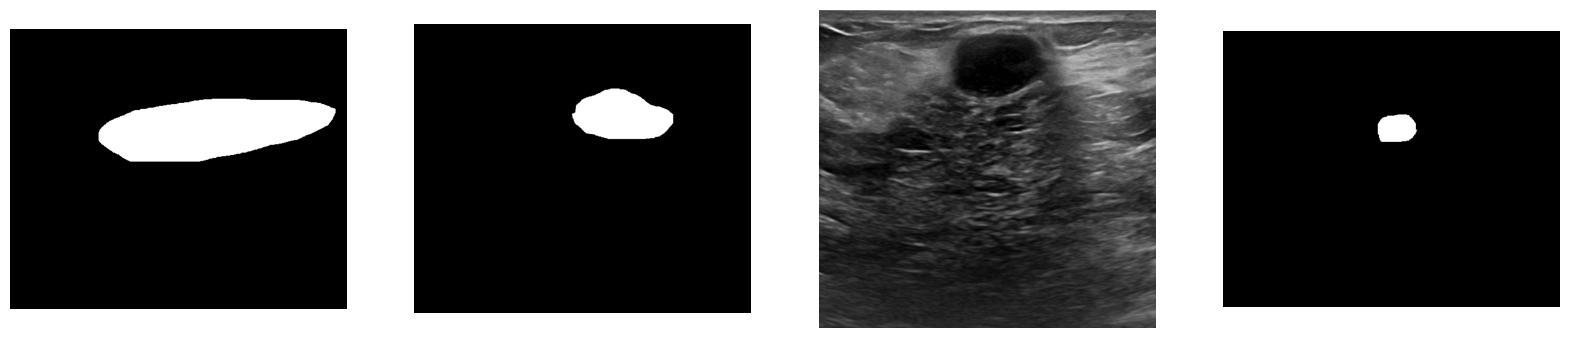

In [12]:
# ==============================================================
# 10. Display Sample Images from a Class
# ==============================================================

# ------------------------------
# 10.1 Select a class to sample from
# ------------------------------
class_name = classes[0]                  # Choose the first class in the classes list
print("Selected class:", class_name)     # Print the selected class name

# ------------------------------
# 10.2 Display 4 random sample images from the selected class
# ------------------------------
sample_images(train_dir, class_name)     # Call the sample_images function


Selected class: malignant


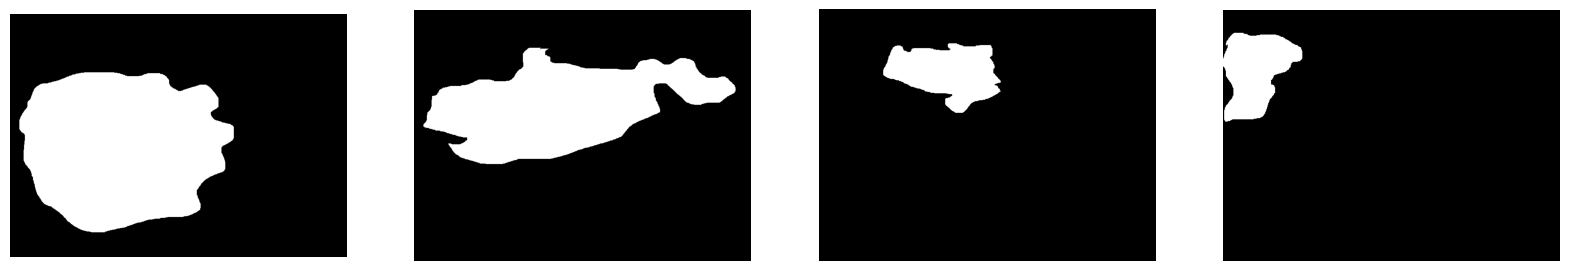

In [13]:
# ==============================================================
# 10. Display Sample Images from a Class
# ==============================================================

# ------------------------------
# 10.1 Select a class to sample from
# ------------------------------
class_name = classes[1]                  # Choose the first class in the classes list
print("Selected class:", class_name)     # Print the selected class name

# ------------------------------
# 10.2 Display 4 random sample images from the selected class
# ------------------------------
sample_images(train_dir, class_name)     # Call the sample_images function


Selected class: normal


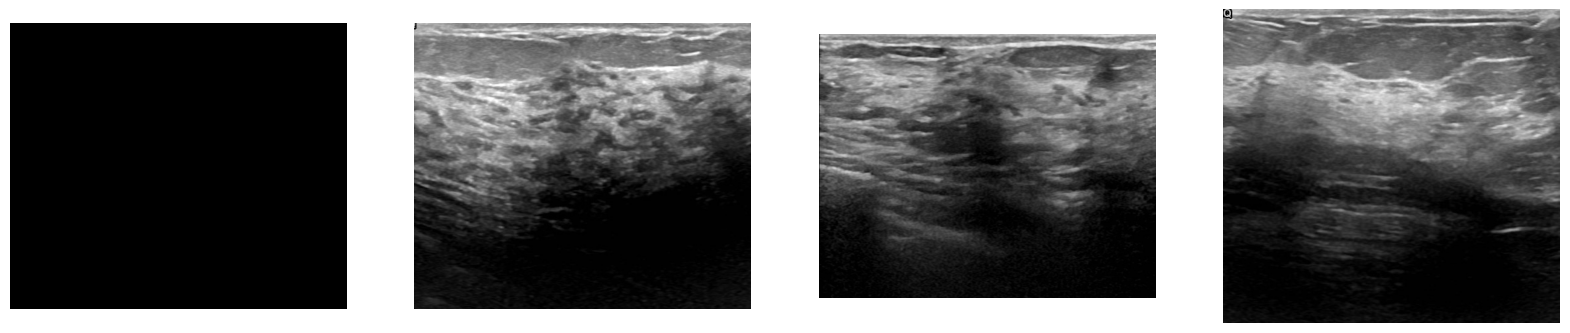

In [14]:
# ==============================================================
# 10. Display Sample Images from a Class
# ==============================================================

# ------------------------------
# 10.1 Select a class to sample from
# ------------------------------
class_name = classes[2]                  # Choose the first class in the classes list
print("Selected class:", class_name)     # Print the selected class name

# ------------------------------
# 10.2 Display 4 random sample images from the selected class
# ------------------------------
sample_images(train_dir, class_name)     # Call the sample_images function


In [15]:
# ------------------------------
# 11.1 Load pre-trained ResNet50 model
# ------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)  
# Using ImageNet pre-trained weights for transfer learning

# ------------------------------
# 11.2 Modify the final fully connected layer
# ------------------------------
num_features = model.fc.in_features        # Get the number of input features to the final layer
model.fc = nn.Linear(num_features, 3)      # Replace final layer with new layer for 3 classes

# ------------------------------
# 11.3 Move model to device (CPU or GPU)
# ------------------------------
model = model.to(device)                    # Send model to GPU if available


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]


In [16]:


# ------------------------------
# 12.1 Define Loss Function
# ------------------------------
# Using CrossEntropyLoss for multi-class classification
# Applying class weights to handle class imbalance
criterion = nn.CrossEntropyLoss(weight=weights)

# ------------------------------
# 12.2 Define Optimizer
# ------------------------------
# Using Adam optimizer for faster convergence
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay = 1e-4)  # Learning rate = 0.0001

# ------------------------------
# 12.3 Define Learning Rate Scheduler
# ------------------------------
# Reduce learning rate every 5 epochs by a factor of 0.5
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)


In [17]:
# ==============================================================
# 13. Training Loop with Metrics Tracking and Early Stopping
# ==============================================================

# ------------------------------
# 13.1 Training Configuration
# ------------------------------
num_epochs = 100                         # Maximum number of training epochs
early_stop_patience = 20                # Early stopping patience
best_val_loss = float("inf")            # Initialize best validation loss
early_stop_counter = 0                  # Counter for early stopping
best_model_path = "Breast2_lump_best_weights.pth"  # Path to save best model

# ------------------------------
# 13.2 Metrics Tracking
# ------------------------------
train_losses = []   # Store training loss per epoch
val_losses = []     # Store validation loss per epoch
train_accs = []     # Store training accuracy per epoch
val_accs = []       # Store validation accuracy per epoch

print("Starting training...")
print("=" * 80)

# ------------------------------
# 13.3 Epoch Loop
# ------------------------------
for epoch in range(1, num_epochs + 1):
    
    # ---- TRAINING PHASE ----
    model.train()                           # Set model to training mode
    train_loss, train_correct, train_total = 0, 0, 0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} [Train]")
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)  # Send batch to device
        
        optimizer.zero_grad()                # Clear gradients
        outputs = model(images)             # Forward pass
        loss = criterion(outputs, labels)   # Compute loss
        
        loss.backward()                      # Backward pass
        optimizer.step()                     # Update weights
        
        batch_size = images.size(0)
        train_loss += loss.item() * batch_size
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += batch_size
        
        # Update progress bar with batch metrics
        train_bar.set_postfix({
            'Loss': f"{loss.item():.4f}",
            'Acc': f"{(outputs.argmax(1) == labels).float().mean().item():.4f}"
        })
    
    # Average metrics over epoch
    train_loss /= len(train_loader.dataset)
    train_acc = train_correct / len(train_loader.dataset)
    
    # ---- VALIDATION PHASE ----
    model.eval()                            # Set model to evaluation mode
    val_loss, val_correct = 0, 0
    
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch}/{num_epochs} [Val]")
    with torch.no_grad():                    # Disable gradient computation
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            
            val_bar.set_postfix({
                'Loss': f"{loss.item():.4f}",
                'Acc': f"{(outputs.argmax(1) == labels).float().mean().item():.4f}"
            })
    
    # Average validation metrics
    val_loss /= len(val_loader.dataset)
    val_acc = val_correct / len(val_loader.dataset)
    
    # ------------------------------
    # 13.4 Store metrics
    # ------------------------------
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # ------------------------------
    # 13.5 Update Learning Rate Scheduler
    # ------------------------------
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # ---- EPOCH SUMMARY ----
    print(f"\nEpoch {epoch} Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print(f"  Learning Rate: {current_lr:.2e}")
    
    # ---- EARLY STOPPING CHECK ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), best_model_path)  # Save best model
        print("  ✓ Model improved - saved")
    else:
        early_stop_counter += 1
        print(f"  ⚠ No improvement: {early_stop_counter}/{early_stop_patience}")
        
        if early_stop_counter >= early_stop_patience:
            print("   Early stopping triggered!")
            break
    
    print("-" * 60)

# ------------------------------
# 13.6 Load Best Model After Training
# ------------------------------
model.load_state_dict(torch.load(best_model_path))
print(f"\nTraining completed! Best validation loss: {best_val_loss:.4f}")


Starting training...


Epoch 1/100 [Train]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/100 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]


Epoch 1 Summary:
  Train Loss: 0.7610 | Train Acc: 0.5135
  Val Loss: 0.6416 | Val Acc: 0.5759
  Learning Rate: 1.00e-04
  ✓ Model improved - saved
------------------------------------------------------------


Epoch 2/100 [Train]:   0%|          | 0/40 [00:00<?, ?it/s]

...

Epoch 50/100 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]


Epoch 50 Summary:
  Train Loss: 0.0438 | Train Acc: 0.9834
  Val Loss: 0.2109 | Val Acc: 0.9399
  Learning Rate: 9.77e-08
  ⚠ No improvement: 19/20
------------------------------------------------------------


Epoch 51/100 [Train]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 51/100 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]


Epoch 51 Summary:
  Train Loss: 0.0482 | Train Acc: 0.9818
  Val Loss: 0.1302 | Val Acc: 0.9494
  Learning Rate: 9.77e-08
  ⚠ No improvement: 20/20
   Early stopping triggered!

Training completed! Best validation loss: 0.1130


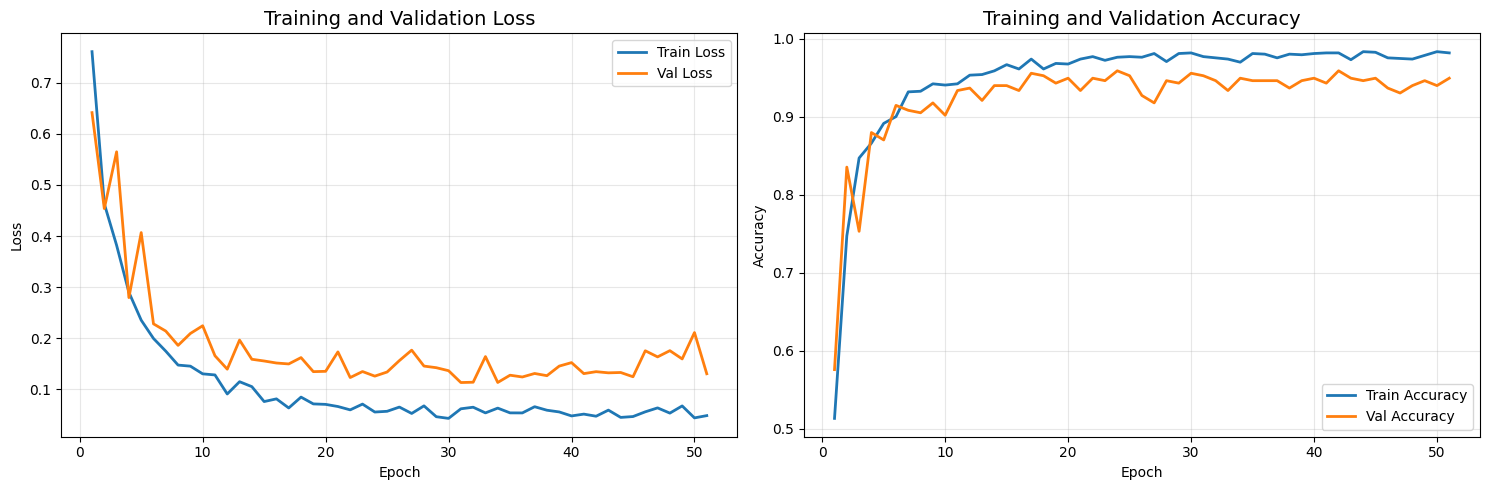

In [18]:
# ==============================================================
# 14. Plot Training and Validation History
# ==============================================================

import matplotlib.pyplot as plt

def plot_training_history(train_losses, val_losses, train_accs, val_accs):
    """
    Plots training and validation loss and accuracy over epochs.

    Parameters:
    - train_losses: list of training losses per epoch
    - val_losses: list of validation losses per epoch
    - train_accs: list of training accuracies per epoch
    - val_accs: list of validation accuracies per epoch
    """
    
    # Create a figure with 2 subplots: Loss and Accuracy
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # ------------------------------
    # 14.1 Loss Plot
    # ------------------------------
    epochs_range = range(1, len(train_losses) + 1)
    ax1.plot(epochs_range, train_losses, label='Train Loss', linewidth=2)
    ax1.plot(epochs_range, val_losses, label='Val Loss', linewidth=2)
    ax1.set_title('Training and Validation Loss', fontsize=14)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # ------------------------------
    # 14.2 Accuracy Plot
    # ------------------------------
    ax2.plot(epochs_range, train_accs, label='Train Accuracy', linewidth=2)
    ax2.plot(epochs_range, val_accs, label='Val Accuracy', linewidth=2)
    ax2.set_title('Training and Validation Accuracy', fontsize=14)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Adjust layout and display plots
    plt.tight_layout()
    plt.show()

# ------------------------------
# 14.3 Plot the training history
# ------------------------------
plot_training_history(train_losses, val_losses, train_accs, val_accs)


Test Set Evaluation:


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

      benign       0.98      0.93      0.95       180
   malignant       0.90      0.96      0.93        83
      normal       0.95      0.98      0.96        53

    accuracy                           0.95       316
   macro avg       0.94      0.96      0.95       316
weighted avg       0.95      0.95      0.95       316



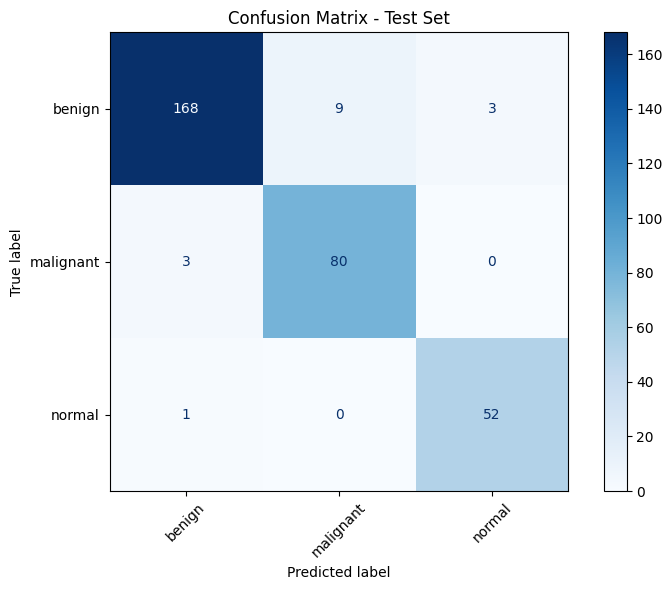

In [19]:
# ==============================================================
# 15. Model Evaluation on Test Set
# ==============================================================

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import torch

# ------------------------------
# 15.1 Function to evaluate model
# ------------------------------
def evaluate_model(model, dataloader, class_names):
    """
    Evaluates the model on a given dataloader and returns predictions, labels, and probabilities.

    Parameters:
    - model: trained PyTorch model
    - dataloader: DataLoader for evaluation dataset
    - class_names: list of class names

    Returns:
    - all_preds: list of predicted class indices
    - all_labels: list of true class indices
    - all_probs: list of predicted probabilities for each class
    """
    model.eval()                      # Set model to evaluation mode
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():             # Disable gradient computation
        for images, labels in tqdm(dataloader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)    # Convert logits to probabilities
            preds = torch.argmax(outputs, 1)        # Get predicted class indices

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return all_preds, all_labels, all_probs

# ------------------------------
# 15.2 Evaluate model on test set
# ------------------------------
print("Test Set Evaluation:")
test_preds, test_labels, test_probs = evaluate_model(model, val_loader, classes)

# ------------------------------
# 15.3 Print classification report
# ------------------------------
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=classes))

# ------------------------------
# 15.4 Compute and plot confusion matrix
# ------------------------------
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - Test Set')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
